https://ieeexplore.ieee.org/document/10121682/metrics#metrics  
Multi-Task EEG Signal Classification Using Correlation-Based IMF Selection and Multi-Class CSP  
使用基於相關的 IMF 選擇和多類 CSP 進行多任務 EEG 訊號分類  

---
##### Activate virtual environment.
```
.\venv\Scripts\Activate.ps1
```
---
Dependency package:
```
pip install ipykernel
pip install numpy
pip install scipy
pip install matplotlib
pip install scikit-learn
pip install mne
pip install pandas
pip install PyQt6
pip install pyvista, pyvistaqt, vtk, qtpy, ipympl, pyqtgraph, mne-qt-browser, ipywidgets, trame_client, trame_server, trame_vtk, trame_vuetify
pip install ipympl
```
---

In [1]:
# 在您的 notebook 最頂端加入這兩行
import matplotlib.pyplot as plt
# %matplotlib widget
%matplotlib inline

import numpy as np
import scipy.io as sio

import matplotlib
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ShuffleSplit, KFold , cross_val_score , train_test_split , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA, FastICA
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

import mne
from mne.datasets import sample
from mne.decoding import UnsupervisedSpatialFilter
from mne.io import concatenate_raws, read_raw_edf
from mne import Epochs, events_from_annotations, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.decoding import CSP
import pandas as pd



# BCIC IV set IIa 數據集
https://github.com/bregydoc/bcidatasetIV2a

https://github.com/KaysenWB/EEG-MI-BCI/blob/main/EEG-BCI/dataloader.py

In [2]:
### cuda and pytorch test
import torch
torch.cuda.is_available()

False

## Prarameter Setup
設定功能。

In [3]:
ifplot = False # 要不要繪製圖片

## Function

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from torch.utils.data import Dataset,DataLoader
from sklearn.preprocessing import StandardScaler
import scipy.io as sio
import torch


class MotorImageryDataset:
    def __init__(self, dataset='A01T.npz'):
        if not dataset.endswith('.npz'):
            dataset += '.npz'   

        path = "..\\dataset\\bcidatasetIV2a-master"
        #path = "C:\\Users\\Kerwin\\EEG_Dataset\\bcidatasetIV2a-master"

        self.data = np.load(f"{path}\\{dataset}")

        self.Fs = 250  # 250Hz from original paper

        # keys of data ['s', 'etyp', 'epos', 'edur', 'artifacts']

        self.raw = self.data['s'].T
        self.events_type = self.data['etyp'].T #'etyp' 存儲事件類型信息
        self.events_position = self.data['epos'].T #'epos' 記錄了每個事件的起始位置
        self.events_duration = self.data['edur'].T #'edur' 記錄了每個事件的持續時間
        self.artifacts = self.data['artifacts'].T #'artifacts' 存儲了人工標記的雜訊或干擾信息

        # Types of motor imagery817000

        self.mi_types = {769: 'left', 770: 'right',
                         771: 'foot', 772: 'tongue', 783: 'unknown'}

    def get_trials_from_channel(self, channel=7):

        # Channel default is C3

        startrial_code = 768
        starttrial_events = self.events_type == startrial_code
        idxs = [i for i, x in enumerate(starttrial_events[0]) if x] #提取所有試驗開始的位置索引

        trials = []
        classes = []

        for index in idxs:
            try:
                type_e = self.events_type[0, index+1] #取得試驗開始位置的下一個事件（index+1），例如：如果 index 位置是 768（試驗開始），index+1 可能是 769（左手）
                class_e = self.mi_types[type_e] #將事件代碼轉換為對應的類別名稱，例如：769 轉換為 'left'
                classes.append(class_e)

                start = self.events_position[0, index] #- - 獲取試驗的開始位置（時間點）
                stop = start + self.events_duration[0, index] #計算試驗的結束位置（時間點）
                trial = self.raw[channel, start:stop] #從指定通道提取這段時間內的腦電信號數據
                trial = trial.reshape((1, -1)) #將試驗數據重塑為二維數組，1 表示一個試驗，-1 表示自動計算另一個維度
                trials.append(trial)

            except:
                continue

        return trials, classes

    def get_trials_from_channels(self, channels=[7, 9, 11]):
        trials_c = []
        classes_c = []
        for c in channels:
            t, c = self.get_trials_from_channel(channel=c) #t 獲取該通道的試驗數據，c 獲取對應的類別標籤

            tt = np.concatenate(t, axis=0) #np.concatenate(t, axis=0) 將同一通道的所有試驗數據沿第一個維度連接
            trials_c.append(tt)
            classes_c.append(c)

        return trials_c, classes_c


class BCIDataset(Dataset):
    def __init__(self, args, training=True):
        self.rate = args.test_rate
        self.label_dict = args.label_dict
        self.training = training
        self.batch = args.batch
        self.mi_types = {769: 'left', 770: 'right',
                         771: 'foot', 772: 'tongue', 783: 'unknown'}

        self.x, self.y = self.load_data(args.subject, args.electrodes)
        minft = self.x.min()
        maxft = self.x.max()
        self.x = ((self.x - minft)/(maxft - minft))


    def load_data(self, subject, electrodes):
        trs,cls = [],[]
        for sub in subject:
            datasets = MotorImageryDataset(f'A0{sub}T.npz')
            print(datasets.data.files)
            input()
            trials_, classes_ = datasets.get_trials_from_channels(electrodes)
            trials = np.stack(trials_, axis=1).astype('float32')
            classes = [self.label_dict[la] for la in classes_[0]]

            border = int(len(classes) * (1 - self.rate))

            if self.training == True:
                trs.append(trials[:border])
                cls += classes[:border]
            else:
                trs.append(trials[border:])
                cls += classes[border:]

        trs = np.concatenate(trs,axis=0)

        return trs, cls


    def __len__(self):
        return len(self.x) - self.batch

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]



# 前處理

In [5]:
#### 實驗參數設定 ####
# EEG-MI 受試者
participants = []
participantsNum = 9
for i in range(1,participantsNum+1,1):
    participants = participants + [f'A0{i}T']
print(f"participants={participants}")

# EEG-MI 任務總類
classNum = 2
classType = [i for i in range(classNum)]
# print(classType)

# Sample rate
fs = 250  # 250Hz from original paper

participants=['A01T', 'A02T', 'A03T', 'A04T', 'A05T', 'A06T', 'A07T', 'A08T', 'A09T']


In [6]:
# 假設 args 包含必要的參數
class Args:
    def __init__(self):
        self.test_rate = 0.2  # 測試集比例
        self.label_dict = {'left': 0, 'right': 1, 'foot': 2, 'tongue': 3}  # 標籤對應
        self.subject = ['1', '2', '3', '4', '5', '6', '7', '8', '9']  # A01T ~ A09T
        self.electrodes = list(range(22)) # [0:21] EEGs, [22:24] EOGs
        # self.electrodes = [7, 9, 11]  # 要使用的通道
        # self.electrodes = [2, 13, 22]  # 要使用的通道
        self.batch = 32  # 批次大小

args = Args()

# 儲存每個受試者的資料
subject_data = {}

for sub in args.subject:
    print(f"處理受試者 A0{sub}T...")


    # 建立 MotorImageryDataset 實例
    dataset = MotorImageryDataset(f'A0{sub}T.npz')
    # print(f"dataset.raw.shape={dataset.raw.shape}")
    # print(dataset.events_type.shape)
    # print(dataset.events_position.shape)
    # print(dataset.events_duration.shape)
    # print(dataset.artifacts.shape)
    # 提取此受試者的 trials 和 classes
    trials, classes = dataset.get_trials_from_channels(args.electrodes)
    trials = np.stack(trials, axis=1).astype('float32')
    classes = [args.label_dict[cls] for cls in classes[0]]

    # 過濾只保留 'left' 和 'right' 的數據
    filtered_trials = []
    filtered_classes = []
    for trial, cls in zip(trials, classes):
        if cls in classType:  # 只保留 'left' (0) 和 'right' (1)
            filtered_trials.append(trial)
            filtered_classes.append(cls)

    filtered_trials = np.array(filtered_trials)
    filtered_classes = np.array(filtered_classes)

    # 劃分訓練集和測試集
    border = int(len(filtered_classes) * (1 - args.test_rate))
    subject_data[f'A0{sub}T'] = {
        'all': {
            'trs': filtered_trials,
            'cls': filtered_classes
        },
        'training': {
            'trs': filtered_trials[:border],
            'cls': filtered_classes[:border]
        },
        'testing': {
            'trs': filtered_trials[border:],
            'cls': filtered_classes[border:]
        }
    }

# 確認每個受試者的資料
for subject, data in subject_data.items():
    print(f"\n受試者: {subject}")
    print(f"  所有數據形狀: {data['all']['trs'].shape}")
    print(f"  所有類別標籤數量: {data['all']['cls'].shape}")
    print(f"  訓練集試驗數據形狀: {data['training']['trs'].shape}")
    print(f"  訓練集類別標籤數量: {data['training']['cls'].shape}")
    print(f"  測試集試驗數據形狀: {data['testing']['trs'].shape}")
    print(f"  測試集類別標籤數量: {data['testing']['cls'].shape}")


處理受試者 A01T...
處理受試者 A02T...
處理受試者 A03T...
處理受試者 A04T...
處理受試者 A05T...
處理受試者 A06T...
處理受試者 A07T...
處理受試者 A08T...
處理受試者 A09T...

受試者: A01T
  所有數據形狀: (138, 22, 1875)
  所有類別標籤數量: (138,)
  訓練集試驗數據形狀: (110, 22, 1875)
  訓練集類別標籤數量: (110,)
  測試集試驗數據形狀: (28, 22, 1875)
  測試集類別標籤數量: (28,)

受試者: A02T
  所有數據形狀: (136, 22, 1875)
  所有類別標籤數量: (136,)
  訓練集試驗數據形狀: (108, 22, 1875)
  訓練集類別標籤數量: (108,)
  測試集試驗數據形狀: (28, 22, 1875)
  測試集類別標籤數量: (28,)

受試者: A03T
  所有數據形狀: (137, 22, 1875)
  所有類別標籤數量: (137,)
  訓練集試驗數據形狀: (109, 22, 1875)
  訓練集類別標籤數量: (109,)
  測試集試驗數據形狀: (28, 22, 1875)
  測試集類別標籤數量: (28,)

受試者: A04T
  所有數據形狀: (129, 22, 1875)
  所有類別標籤數量: (129,)
  訓練集試驗數據形狀: (103, 22, 1875)
  訓練集類別標籤數量: (103,)
  測試集試驗數據形狀: (26, 22, 1875)
  測試集類別標籤數量: (26,)

受試者: A05T
  所有數據形狀: (129, 22, 1875)
  所有類別標籤數量: (129,)
  訓練集試驗數據形狀: (103, 22, 1875)
  訓練集類別標籤數量: (103,)
  測試集試驗數據形狀: (26, 22, 1875)
  測試集類別標籤數量: (26,)

受試者: A06T
  所有數據形狀: (113, 22, 1875)
  所有類別標籤數量: (113,)
  訓練集試驗數據形狀: (90, 22, 1875)
  訓練集類別標籤數量: (90,)
  測試集試驗數據形狀

## 所有受試者濾波

In [7]:
from scipy import signal

class bandpass_filter:
    def __init__(self, lowcut, highcut, fs, order=5):
        self.lowcut = lowcut
        self.highcut = highcut
        self.fs = fs
        self.order = order
        self.nyq = 0.5 * fs
        self.low = lowcut / self.nyq
        self.high = highcut / self.nyq
        self.b, self.a = signal.butter(order, [self.low, self.high], btype='band')

    def plotFilterFrequencyResponse(self, b, a, nyq):
        w, h = signal.freqz(b, a, worN=8000)
        frequencies = (w / np.pi) * nyq
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
        # 绘制幅度响应图
        ax1.plot(frequencies, 20 * np.log10(abs(h)), label=f'Order {order} Butterworth')
        ax1.set_title('Filter Frequency Response')
        ax1.set_ylabel('Magnitude [dB]')
        ax1.axvline(lowcut, color='r', linestyle='--', label=f'Lowcut ({lowcut} Hz)')
        ax1.axvline(highcut, color='g', linestyle='--', label=f'Highcut ({highcut} Hz)')
        ax1.axhline(-3, color='k', linestyle=':', label='-3 dB (Half-power point)')
        ax1.set_ylim(-60, 5)
        ax1.legend()
        ax1.grid(True, which='both')
        # 绘制相位响应图
        angles = np.unwrap(np.angle(h)) * 180 / np.pi # 解卷绕并转换为角度
        ax2.plot(frequencies, angles)
        ax2.set_title('Phase Response')
        ax2.set_xlabel('Frequency [Hz]')
        ax2.set_ylabel('Phase [degrees]')
        ax2.axvline(lowcut, color='r', linestyle='--')
        ax2.axvline(highcut, color='g', linestyle='--')
        ax2.grid(True, which='both')
        plt.tight_layout()
        plt.show()
        fig.savefig(f"{self.order}Order_ButterworthFilter_FrequencyResponse")

# ... bandpass_filter function and imports remain the same ...

fs = 250  # Sampling frequency
lowcut = 8  # Low cutoff frequency
highcut = 30  # High cutoff frequency
order = 8  # Filter order


# 遍歷所有受試者
BPFilter = bandpass_filter(lowcut, highcut, fs, order)

for subject in participants:
    filtered_trs = []
    for trial in subject_data[subject]['all']['trs']:
        for channel in range(trial.shape[0]):
            filtered_channel = signal.filtfilt(BPFilter.b, BPFilter.a, trial[channel])
            filtered_trs.append(filtered_channel)
    filtered_trs = np.array(filtered_trs).reshape(subject_data[subject]['all']['trs'].shape)
    subject_data[subject]['all']['filtered_trs'] = filtered_trs
    print(f"Subject {subject} pre-filt data shape: {subject_data[subject]['all']['trs'].shape}")
    print(f"Subject {subject} filtered data shape: {subject_data[subject]['all']['filtered_trs'].shape}")

if ifplot:
    BPFilter.plotFilterFrequencyResponse(BPFilter.b, BPFilter.a, BPFilter.nyq)


Subject A01T pre-filt data shape: (138, 22, 1875)
Subject A01T filtered data shape: (138, 22, 1875)
Subject A02T pre-filt data shape: (136, 22, 1875)
Subject A02T filtered data shape: (136, 22, 1875)
Subject A03T pre-filt data shape: (137, 22, 1875)
Subject A03T filtered data shape: (137, 22, 1875)
Subject A04T pre-filt data shape: (129, 22, 1875)
Subject A04T filtered data shape: (129, 22, 1875)
Subject A05T pre-filt data shape: (129, 22, 1875)
Subject A05T filtered data shape: (129, 22, 1875)
Subject A06T pre-filt data shape: (113, 22, 1875)
Subject A06T filtered data shape: (113, 22, 1875)
Subject A07T pre-filt data shape: (133, 22, 1875)
Subject A07T filtered data shape: (133, 22, 1875)
Subject A08T pre-filt data shape: (132, 22, 1875)
Subject A08T filtered data shape: (132, 22, 1875)
Subject A09T pre-filt data shape: (116, 22, 1875)
Subject A09T filtered data shape: (116, 22, 1875)


## Function：EEG訊號濾波前後打印出來 可調整打印出來的是第幾次試驗第幾通道C3 Cz C4

In [8]:
#@title 單獨測試 EEG訊號濾波前後打印出來 可調整打印出來的是第幾次試驗第幾通道C3 Cz C4
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
def plot_signal_and_fft(data, fs, title):
    t = np.arange(len(data)) / fs

    # 計算FFT
    n = len(data)
    yf = fft(data)
    xf = fftfreq(n, 1/fs)[:n//2]
    xftset = n/fs

    # 繪製時域波形和頻域圖
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 2))

    # 時域波形
    ax1.plot(t, data)
    ax1.set_title(f'{title} - Time Domain')
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Amplitude')
    ax1.set_xlim()
    x_step = 0.5 # 時序圖間格 單位:s
    ax1.set_xticks(np.arange(0, len(t)/fs+1, x_step))

    # 頻域圖
    ax2.plot(xf, 2.0/n * np.abs(yf[0:n//2]))
    ax2.set_title(f'{title} - Frequency Domain')
    ax2.set_xlabel('Frequency [Hz]')
    ax2.set_ylabel('Magnitude')
    ax2.set_xlim(0, fs/2)  # 只顯示到奈奎斯特頻率
    x_step = 10 # 頻譜圖間格 單位:Hz
    ax2.set_xticks(np.arange(0, fs / 2 + 1, x_step))
    ax2.set_yticks(np.arange(0, 3.6, 0.5))

    plt.tight_layout()
    plt.show()
    name = title.split(' ')
    name = '_'.join(name) + ".png"
    fig.savefig(name)


## 繪製EEG訊號濾波前後

In [9]:
# 假設我們選擇第一個試驗的第一個通道的數據例如，要查看第二個試驗的第三個通道，可以使用：sample_data = eeg_data[1, 2, :]
# MI_data = subject_data['A01T']['all']['filtered_trs'][:,:,3*fs:6*fs]
# sample_data = MI_data[0, 0, :]
Ch_name = ['C3','Cz','C4'] # 9, 11, 13
electrodes = [9, 11, 13]
recordStart = 3 # second
recordStop = 6 # second
fs = 250  # 採樣率
# lowcut = 8  # 低頻截止
# highcut = 30  # 高頻截止
if ifplot:
  for idx, ch in  enumerate(electrodes):
    # 繪製原始信號
    fig = plot_signal_and_fft(subject_data['A02T']['all']['trs'][0,ch,3*fs:6*fs], fs, f"ch {Ch_name[idx]} Original Signal")
    # 繪製濾波後的信號
    fig = plot_signal_and_fft(subject_data['A02T']['all']['filtered_trs'][0,ch,3*fs:6*fs], fs, f"ch {Ch_name[idx]} Filtered Signal")

## 對所有受試者提取 epochs

In [10]:
# 對所有受試者提取 epochs
recordStart = 3 # second
recordStop = 6 # second
subject_data_epoch = {}
subject_event_epoch = {}
for subject in participants:
    # 提取 3-6 秒的 MI 資料
    raw_data = subject_data[subject]['all']['trs'][:,:,recordStart*fs:recordStop*fs]
    raw_event = subject_data[subject]['all']['cls']
    # raw_data = subject_data[subject]['all']['filtered_trs'][:,:,recordStart*fs:recordStop*fs]
    # 按照subjects 建立 epochs
    # 例如 subject_data_epoch['A01T'] = np.array(raw_data)
    subject_data_epoch[subject] = raw_data
    subject_event_epoch[subject] = raw_event

print(f"subject_data_epoch={(subject_data_epoch[subject]).shape}")
print(f"raw_event={subject_event_epoch[subject].shape}")

subject_data_epoch=(116, 22, 750)
raw_event=(116,)


## 原始訊號視覺化


In [11]:
ch_names = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 
    'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 
    'P2', 'POz']

## Parameter ##
sfreq = 250  # sampling frequency or sampling rate
ch_types = ['eeg']*len(ch_names)  # subject_data_epoch對應到的22個電極是什麼訊號
## 透過 mne.create_info創建Info物件，將 np.array 物件轉成 mne.epoch 物件 ##
info = mne.create_info(
    ch_names=ch_names,
    sfreq=sfreq,
    ch_types=ch_types
)

# (option) 設置標準的電極位置，這樣 MNE 才能畫出正確的頭皮地形圖
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

print("\n創建的 MNE Info 物件:")
print(info)


創建的 MNE Info 物件:
<Info | 8 non-empty values
 bads: []
 ch_names: Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, ...
 chs: 22 EEG
 custom_ref_applied: False
 dig: 25 items (3 Cardinal, 22 EEG)
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 22
 projs: []
 sfreq: 250.0 Hz
>


In [12]:
# 在您的 notebook 最頂端加入這兩行
import matplotlib.pyplot as plt
# %matplotlib widget
%matplotlib inline

## 印出每個受試者資料大小/資料分布對大值/最小值
for idx, subject in enumerate(participants):
    print(f"subject_data_epoch['A01T'] shape={subject_data_epoch[subject].shape}")
    # print("Channel names:", epochs.ch_names)
    # print("Channel types:", epochs.get_channel_types())
    print(f"np.max(subject_data_epoch[{subject}][0,0,:]={np.max(subject_data_epoch[subject][0,0,:])}")
    print(f"np.max(subject_data_epoch[{subject}][0,0,:]={np.min(subject_data_epoch[subject][0,0,:])}")
    print()
    
## 將 NumPy 數據和 Info 物件結合，創建出 MNE 可以操作的 EpochsArray
# 每個subject要單獨先分析，之後再透過evokeds一起分析
epochs_all = {}
for subject in participants:
    print(f"build {subject} epoch")
    your_numpy_data = subject_data_epoch[subject] 
    data_in_volts = your_numpy_data / 1_000_000.0
    ## 看 data 電壓範圍
    # print(f"data_in_volts[0,0,:]={np.max(data_in_volts[0,0,:])}")
    # print(f"data_in_volts[0,0,:]={np.min(data_in_volts[0,0,:])}")
    ##　創建 EpochsArray 物件
    epochs = mne.EpochsArray(data_in_volts, info)
    # print("\n成功創建 EpochsArray 物件:")
    # print(epochs)

    # ##　開始進行標準的 MNE 分析與視覺化
    if ifplot:
        # ## 1. 視覺化檢查所有 trials
        # ## MNE 會將 116 個 trial 疊在一起繪製，方便您檢查一致性
        picks = ['Fz', 'C3', 'Cz', 'C4', 'Pz']
        n_channels = len(picks)
        fig = epochs.plot(picks=picks, n_channels=n_channels, n_epochs=1, show=False) # 畫 10 個 eeg 通道, 5 個 trials
        fig.savefig(f'epoch_rawdata_{subject}.png')

        # 2. 計算平均事件相關電位 (ERP)
        # .average() 方法會將 116 個 trial 平均起來，得到 Evoked 物件
        evoked = epochs.average()
        # print("\n平均後的 Evoked 物件:")
        # print(evoked)

        # 4. 繪製頭皮地形圖 (Topomap)
        # 顯示在不同時間點，整個頭皮的電位分佈
        times = np.arange(0, 3.00, 0.5)
        print(f"{subject} topomap")
        fig = evoked.plot_topomap(times=times, ch_type='eeg')
        fig.savefig(f'evoked_topomap_{subject}.png')

        # 5. 繪製一個非常實用的組合圖 (Joint Plot)
        # 它同時顯示了波形和地形圖，可以清楚看到 ERP 成分的時空動態
        print(f"{subject} ERP Waveform and Topomap")
        fig = evoked.plot_joint(times=times, picks='eeg', title="ERP Waveform and Topomap")
        fig.savefig(f'evoked_TopomapAndWaveform_{subject}.png')

        print(f"{subject} Plot Success")

    epochs_all[subject] = epochs

subject_data_epoch['A01T'] shape=(138, 22, 750)
np.max(subject_data_epoch[A01T][0,0,:]=29.58984375
np.max(subject_data_epoch[A01T][0,0,:]=-26.66015625

subject_data_epoch['A01T'] shape=(136, 22, 750)
np.max(subject_data_epoch[A02T][0,0,:]=53.02734375
np.max(subject_data_epoch[A02T][0,0,:]=-30.2734375

subject_data_epoch['A01T'] shape=(137, 22, 750)
np.max(subject_data_epoch[A03T][0,0,:]=23.876953125
np.max(subject_data_epoch[A03T][0,0,:]=-20.263671875

subject_data_epoch['A01T'] shape=(129, 22, 750)
np.max(subject_data_epoch[A04T][0,0,:]=25.244140625
np.max(subject_data_epoch[A04T][0,0,:]=-25.341796875

subject_data_epoch['A01T'] shape=(129, 22, 750)
np.max(subject_data_epoch[A05T][0,0,:]=28.173828125
np.max(subject_data_epoch[A05T][0,0,:]=-32.03125

subject_data_epoch['A01T'] shape=(113, 22, 750)
np.max(subject_data_epoch[A06T][0,0,:]=29.638671875
np.max(subject_data_epoch[A06T][0,0,:]=-24.12109375

subject_data_epoch['A01T'] shape=(133, 22, 750)
np.max(subject_data_epoch[A07T][0,0,:]

## CSP+結果視覺化

In [13]:
csp_results = {}
for subject in participants:
    # --- 步驟 1: 進行頻帶濾波 (關鍵前處理) ---
    # 對於運動想像，通常濾波在 mu 節律 (8-30 Hz)
    # 提醒會用到的參數
    lowcut = lowcut
    highcut = highcut
    epochs_filtered = epochs_all[subject].copy().filter(l_freq=lowcut, h_freq=highcut, fir_design='firwin')
    # --- 步驟 2: 準備數據 (X) 和標籤 (y) ---
    X = epochs_all[subject].get_data()
    y = subject_event_epoch[subject]
    print(f"{subject} epochs data shape: {X.shape}")
    print(f"{subject} event epoch shape: {y.shape}")
    # --- 步驟 3: 初始化並訓練 CSP 模型 ---
    # n_components 決定了我們要保留多少個空間濾波器。通常設為一個較小的偶數。
    channels = 22
    M = 3 # 保留前5個和後5個
    n_components = 2*M
    csp = CSP(n_components=n_components, reg=None, log=True, norm_trace=False)
    # --- 步驟 4: 訓練 CSP 並轉換數據 ---
    # csp.fit_transform 會學習空間濾波器，並將原始數據轉換為新的特徵
    X_csp = csp.fit_transform(X, y)
    print(f"經過 CSP 轉換後，數據 X_csp 的維度: {X_csp.shape}") # 應該是 (138, 4)
    # --- 步驟 5: 視覺化 CSP 空間模式 (Spatial Patterns) ---
    # 這一步可以幫助我們理解 CSP 找到了什麼樣的腦區活動模式
    # csp.plot_patterns() 會畫出最具區分性的腦波地形圖
    if ifplot:
        print("\n正在繪製 CSP 空間模式圖...")
        fig = csp.plot_patterns(epochs_all[subject].info, ch_type='eeg', units='A.U.', size=1.5)
        fig.suptitle(f"{subject} CSP Spatial Patterns")
        fig.savefig(f"{subject} CSP topomap")
        plt.show()

        # 您也可以畫出空間濾波器本身
        # csp.plot_filters(epochs_all[subject].info, ch_type='eeg', units='A.U.', size=1.5)
        # plt.suptitle("CSP filter")
        # plt.show()

    # 儲存結果
    labels = subject_data[subject]['all']['cls']
    csp_results[subject] = {
        'X_csp': np.vstack(X_csp),
        'y_csp': np.hstack(labels),
        'csp_model': csp
    }
    # 印出處理結果的形狀
    print(f"Subject {subject} CSP features shape: {csp_results[subject]['X_csp'].shape}")

    # # --- (可選) 步驟 6: 使用 CSP 特徵進行分類 ---
    # # CSP 的最終目的是為了分類，這裡展示一個完整的訓練和測試流程

    # # 1. 切分訓練集和測試集
    # X_train, X_test, y_train, y_test = train_test_split(X_csp, y, test_size=0.2, random_state=42)

    # # 2. 建立一個分類器 (線性判別分析 LDA 是 BCI 的常用選擇)
    # lda = LinearDiscriminantAnalysis()

    # # 3. 訓練分類器
    # lda.fit(X_train, y_train)

    # # 4. 評估模型準確率
    # score = lda.score(X_test, y_test)

    # print(f"\n {subject} 使用 CSP + LDA 分類器的準確率為: {score * 100:.2f}%")

Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

A01T epochs data shape: (138, 22, 750)
A01T event epoch shape: (138,)
Computing rank from data with rank=None
    Using tolerance 6.5e-05 (2.2e-16 eps * 22 dim * 1.3e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
經過 CSP 轉換後，數據 X_csp 的維度: (138, 6)
Subject A01T CSP feature

## CSP特徵PCA，3 Dim

In [14]:
# Cell 1: 環境配置

# 確保動畫使用 JavaScript/HTML 方式渲染，這是 Jupyter 的標準做法
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["animation.html"] = "jshtml" 

# 如果您希望圖形窗口獨立彈出 (而不是嵌入 Notebook)，可以嘗試:
# %matplotlib notebook 
# 或者如果所有方法都失敗，且您安裝了 ffmpeg：
# plt.rcParams['animation.writer'] = 'ffmpeg' 

print("Matplotlib 動畫渲染方式已設置為 'jshtml'")


# Cell 2: 主程式碼

import numpy as np
from mpl_toolkits.mplot3d import Axes3D 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.animation as animation 
# 由於 plt.rcParams["animation.html"] = "jshtml" 已經設置，這裡無需再次 import plt

# 確保您可以直接在 Jupyter 中顯示動畫對象
from IPython.display import display

Matplotlib 動畫渲染方式已設置為 'jshtml'


In [15]:
if ifplot:
# if True:
    def update_graph(num, scatters, ax):
        """ 更新 3D 散點圖的視角（方位角）"""
        # 旋轉速率：num * 4
        ax.view_init(elev=20, azim=num * 4) 
        return scatters 


    for subject in participants:
        print(f"--- Processing Subject: {subject} (Generating Animation) ---")
        
        # 1. 數據提取與修正
        X_result = csp_results[subject]['X_csp']
        y = csp_results[subject]['y_csp']
        
        # 2. 標準化
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_result) 

        # 3. PCA 降維
        pca = PCA(n_components=3) 
        X_pca = pca.fit_transform(X_scaled)
        variance_ratio = pca.explained_variance_ratio_

        # 4. 繪圖初始化
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        targets = [0, 1]
        colors = ['r', 'b']  
        labels = ['Left Hand Imagery', 'Right Hand Imagery']
        scatters = [] 

        for target, color, label in zip(targets, colors, labels):
            indicesToKeep = y == target
            scatter = ax.scatter(
                X_pca[indicesToKeep, 0], 
                X_pca[indicesToKeep, 1], 
                X_pca[indicesToKeep, 2], 
                c = color, 
                s = 50, 
                label = label,
                alpha=0.7 
            )
            scatters.append(scatter) 

        # 設置標籤
        ax.set_xlabel(f'PC 1 ({variance_ratio[0]*100:.2f}%)')
        ax.set_ylabel(f'PC 2 ({variance_ratio[1]*100:.2f}%)')
        ax.set_zlabel(f'PC 3 ({variance_ratio[2]*100:.2f}%)')
        ax.set_title(f'{subject}: 3D PCA of CSP Features (Rotating View)')
        ax.legend()
        
        # 5. 創建動畫
        ani = animation.FuncAnimation(
            fig, 
            update_graph, 
            frames=range(0, 360//4), 
            fargs=(scatters, ax), 
            interval=50, 
            blit=False
        )
        
        # 6. 顯示動畫
        # 關閉靜態圖，確保 Notebook 只顯示動畫
        plt.close(fig) 
        # 使用 IPython.display 顯示動畫對象
        display(ani) 

        # 7. 總方差貢獻率輸出
        total_variance = (variance_ratio[0] + variance_ratio[1] + variance_ratio[2]) * 100
        print("PCA 總共保留的方差貢獻率 (PC1 + PC2 + PC3):")
        print(f"{total_variance:.2f}%\n")

## CSP特徵PCA，2 Dim

In [16]:
# if True:
if ifplot:
    # 原始CSP特徵PCA
    for subject in participants:
        X_result = csp_results[subject]['X_csp']
        y = csp_results[subject]['y_csp']
        # -------------------- 1. 標準化 (Standardization) --------------------
        # 這是應用 PCA 之前的最佳實踐
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_result)

        # -------------------- 2. PCA 降維 (Dimensionality Reduction) --------------------
        # 降到 2 維以便繪圖
        pca = PCA(n_components=3)
        X_pca = pca.fit_transform(X_scaled)
        
        # -------------------- 3. 可視化 (Visualization) --------------------

        plt.figure(figsize=(8, 6))

        # 定義類別標籤和顏色
        targets = [0, 1]
        colors = ['r', 'b']  # 紅色代表左手 (0), 藍色代表右手 (1)
        labels = ['Left Hand Imagery', 'Right Hand Imagery']

        for target, color, label in zip(targets, colors, labels):
            # 選擇屬於當前類別的樣本
            indicesToKeep = y == target
            
            # 繪製散點圖
            plt.scatter(
                X_pca[indicesToKeep, 0], # PC1 (X 軸)
                X_pca[indicesToKeep, 1], # PC2 (Y 軸)
                c = color, 
                s = 50, # 點的大小
                label = label,
                alpha=0.7 # 透明度
            )

        plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
        plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
        plt.title(f'{subject}: 2D PCA of CSP Features')
        plt.legend()
        plt.grid()
        # 檔案名稱格式：{subject}_CSP_PCA_2D.png
        filename = f'CSP_PCA_2D_{subject}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight') 
        print(f"圖片已儲存至：{filename}")
        plt.show()
        

        # -------------------- 4. 判斷特徵有效性 --------------------
        print("\nPCA 總共保留的方差貢獻率 (PC1 + PC2):")
        print(f"{(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])*100:.2f}%")

# 分類

## 分割所有受試者資料

In [17]:
# 創建字典來存儲所有受試者的訓練和測試資料
split_results = {}

# 對所有受試者進行資料分割
for subject in participants:
    # 獲取該受試者的 CSP 特徵和標籤
    X_result = csp_results[subject]['X_csp']
    y_result = csp_results[subject]['y_csp']

    # 分割訓練集和測試集
    X_train, X_test, y_train, y_test = train_test_split(
        X_result, y_result, test_size=0.2, random_state=42
    )

    # 儲存分割結果
    split_results[subject] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

    # 印出每個受試者的資料形狀
    print(f"\nSubject {subject}:")
    print(f"X all shape: {X_result.shape}")
    print(f"X_train shape: {X_train.shape}") # data
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}") # label
    print(f"y_test shape: {y_test.shape}")


Subject A01T:
X all shape: (138, 6)
X_train shape: (110, 6)
X_test shape: (28, 6)
y_train shape: (110,)
y_test shape: (28,)

Subject A02T:
X all shape: (136, 6)
X_train shape: (108, 6)
X_test shape: (28, 6)
y_train shape: (108,)
y_test shape: (28,)

Subject A03T:
X all shape: (137, 6)
X_train shape: (109, 6)
X_test shape: (28, 6)
y_train shape: (109,)
y_test shape: (28,)

Subject A04T:
X all shape: (129, 6)
X_train shape: (103, 6)
X_test shape: (26, 6)
y_train shape: (103,)
y_test shape: (26,)

Subject A05T:
X all shape: (129, 6)
X_train shape: (103, 6)
X_test shape: (26, 6)
y_train shape: (103,)
y_test shape: (26,)

Subject A06T:
X all shape: (113, 6)
X_train shape: (90, 6)
X_test shape: (23, 6)
y_train shape: (90,)
y_test shape: (23,)

Subject A07T:
X all shape: (133, 6)
X_train shape: (106, 6)
X_test shape: (27, 6)
y_train shape: (106,)
y_test shape: (27,)

Subject A08T:
X all shape: (132, 6)
X_train shape: (105, 6)
X_test shape: (27, 6)
y_train shape: (105,)
y_test shape: (27,)

S

## ML分類

In [18]:
## 個別受試者跑ML
# 創建字典來存儲所有受試者的分類結果
classification_results = {}
for subject in participants:
    print(f"\n=== Processing Subject {subject} ===")
    
    # 獲取該受試者的訓練和測試資料
    X_train = split_results[subject]['X_train']
    X_test = split_results[subject]['X_test']
    y_train = split_results[subject]['y_train']
    y_test = split_results[subject]['y_test']
    X_result = np.vstack((X_train, X_test))
    y_result = np.hstack((y_train, y_test))

    # 定義分類器和投票分類器
    svm = SVC(probability=True)
    knn = KNeighborsClassifier()
    lda = LinearDiscriminantAnalysis()
    
    voting_clf = VotingClassifier(
        estimators=[("svm",svm),("knn",knn),('lda', lda)],
        voting='soft'
    )

    # 創建管道
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', voting_clf)
    ])

    # 參數網格
    param_grid = {
        'classifier__svm__C': [0.1, 1, 10],
        'classifier__svm__kernel': ['rbf', 'linear'],
        'classifier__knn__n_neighbors': [5],
        'classifier__knn__weights': ['uniform', 'distance'],
        'classifier__lda__solver': ['svd', 'lsqr', 'eigen']
    }

    # 網格搜索
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)

    # 預測和評估
    y_pred = grid_search.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    cv_scores = cross_val_score(grid_search.best_estimator_, X_result, y_result, cv=5)

    # 儲存結果
    classification_results[subject] = {
        'best_params': grid_search.best_params_,
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'best_model': grid_search.best_estimator_
    }

    # 輸出結果
    print(f"\nSubject {subject} Results:")
    print(f"Best parameters: {grid_search.best_params_}")
    print(f'Accuracy: {accuracy * 100:.2f}%')
    print("\nConfusion Matrix:")
    print(conf_matrix)
    print("\nClassification Report:")
    print(class_report)
    print(f"\nCross-validation scores: {cv_scores}")
    print(f"Mean CV score: {cv_scores.mean():.2f} (+/- {cv_scores.std() * 2:.2f})")

# 計算並顯示所有受試者的平均表現
mean_accuracy = np.mean([results['accuracy'] for results in classification_results.values()])
mean_cv_score = np.mean([results['cv_mean'] for results in classification_results.values()])
print("\n=== Overall Results ===")
print(f"Mean accuracy across all subjects: {mean_accuracy * 100:.2f}%")
print(f"Mean CV score across all subjects: {mean_cv_score:.2f}")


=== Processing Subject A01T ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Subject A01T Results:
Best parameters: {'classifier__knn__n_neighbors': 5, 'classifier__knn__weights': 'distance', 'classifier__lda__solver': 'eigen', 'classifier__svm__C': 0.1, 'classifier__svm__kernel': 'rbf'}
Accuracy: 60.71%

Confusion Matrix:
[[9 8]
 [3 8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.53      0.62        17
           1       0.50      0.73      0.59        11

    accuracy                           0.61        28
   macro avg       0.62      0.63      0.61        28
weighted avg       0.65      0.61      0.61        28


Cross-validation scores: [0.67857143 0.64285714 0.85714286 0.7037037  0.62962963]
Mean CV score: 0.70 (+/- 0.16)

=== Processing Subject A02T ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Subject A02T Results:
Best parameters: {'classifier__knn__n_neighbors': 5, 'clas

In [19]:
## 統整列出每個受試者指標

# 在最後的結果輸出部分添加以下代碼
import pandas as pd
from sklearn.metrics import f1_score

# 創建結果表格
results_data = {
    'Subject': [],
    'Mean CV Score': [],
    'CV Score Std': [],
    'Test Accuracy': [],
    'F1 Score': []
}

for subject, results in classification_results.items():
    results_data['Subject'].append(subject)
    results_data['Mean CV Score'].append(results['cv_mean'])
    results_data['CV Score Std'].append(results['cv_std'])
    results_data['Test Accuracy'].append(results['accuracy'] * 100)
    
    # 計算 F1 score
    y_test = split_results[subject]['y_test']
    y_pred = results['best_model'].predict(split_results[subject]['X_test'])
    f1 = f1_score(y_test, y_pred, average='macro')
    results_data['F1 Score'].append(f1 * 100)

results_df = pd.DataFrame(results_data)

# 添加平均行
mean_row = pd.DataFrame({
    'Subject': ['Average'],
    'Mean CV Score': [results_df['Mean CV Score'].mean()],
    'CV Score Std': [results_df['CV Score Std'].mean()],
    'Test Accuracy': [results_df['Test Accuracy'].mean()],
    'F1 Score': [results_df['F1 Score'].mean()]
})

results_df = pd.concat([results_df, mean_row])

# 設置小數點位數
results_df['Mean CV Score'] = results_df['Mean CV Score'].round(3)
results_df['CV Score Std'] = results_df['CV Score Std'].round(3)
results_df['Test Accuracy'] = results_df['Test Accuracy'].round(2)
results_df['F1 Score'] = results_df['F1 Score'].round(2)

print("\n=== Classification Results for All Subjects ===")
print(results_df.to_string(index=False))

# 保存表格到 CSV 文件
results_df.to_csv('classification_results_with_f1.csv', index=False)


=== Classification Results for All Subjects ===
Subject  Mean CV Score  CV Score Std  Test Accuracy  F1 Score
   A01T          0.702         0.082          60.71     60.66
   A02T          0.713         0.138          82.14     81.94
   A03T          0.912         0.037          96.43     96.02
   A04T          0.720         0.062          61.54     60.61
   A05T          0.805         0.064          61.54     59.38
   A06T          0.700         0.082          69.57     69.33
   A07T          0.803         0.079          66.67     66.48
   A08T          0.932         0.056          92.59     92.50
   A09T          0.776         0.064          75.00     74.83
Average          0.785         0.074          74.02     73.53


# 實驗1: CSP M值設定

## pre-processing

In [20]:
doExp1 = True
if doExp1: # 控制要不要做實驗1
    csp_results = {} # csp_results[subjects][M]
    for subject in participants:
        csp_results[subject] = {}
    channels = 22
    M_list = [i for i in range(1,12)]
    ifplot = False
    for subject in participants:
        for M in M_list:
            # --- 步驟 1: 進行頻帶濾波 (關鍵前處理) ---
            # 對於運動想像，通常濾波在 mu 節律 (8-30 Hz)
            # 提醒會用到的參數
            lowcut = lowcut
            highcut = highcut
            epochs_filtered = epochs_all[subject].copy().filter(l_freq=lowcut, h_freq=highcut, fir_design='firwin')
            # --- 步驟 2: 準備數據 (X) 和標籤 (y) ---
            X = epochs_all[subject].get_data()
            y = subject_event_epoch[subject]
            print(f"{subject} epochs data shape: {X.shape}")
            print(f"{subject} event epoch shape: {y.shape}")
            # --- 步驟 3: 初始化並訓練 CSP 模型 ---
            # n_components 決定了我們要保留多少個空間濾波器。通常設為一個較小的偶數。
            n_components = 2*M
            csp = CSP(n_components=n_components, reg=None, log=True, norm_trace=False)
            # --- 步驟 4: 訓練 CSP 並轉換數據 ---
            # csp.fit_transform 會學習空間濾波器，並將原始數據轉換為新的特徵
            X_csp = csp.fit_transform(X, y)
            print(f"經過 CSP 轉換後，數據 X_csp 的維度: {X_csp.shape}") # 應該是 (138, 4)
            # --- 步驟 5: 視覺化 CSP 空間模式 (Spatial Patterns) ---
            # 這一步可以幫助我們理解 CSP 找到了什麼樣的腦區活動模式
            # csp.plot_patterns() 會畫出最具區分性的腦波地形圖
            if ifplot:
                print("\n正在繪製 CSP 空間模式圖...")
                fig = csp.plot_patterns(epochs_all[subject].info, ch_type='eeg', units='A.U.', size=1.5)
                fig.suptitle(f"{subject} CSP Spatial Patterns")
                fig.savefig(f"{subject} CSP topomap")
                plt.show()

                # 您也可以畫出空間濾波器本身
                # csp.plot_filters(epochs_all[subject].info, ch_type='eeg', units='A.U.', size=1.5)
                # plt.suptitle("CSP filter")
                # plt.show()

            # 儲存結果
            labels = subject_data[subject]['all']['cls']
            csp_results[subject][M] = {
                'X_csp': np.vstack(X_csp),
                'y_csp': np.hstack(labels),
                'csp_model': csp
            }
            # 印出處理結果的形狀
            print(f"Subject {subject} CSP features shape: {csp_results[subject][M]['X_csp'].shape}")


Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

A01T epochs data shape: (138, 22, 750)
A01T event epoch shape: (138,)
Computing rank from data with rank=None
    Using tolerance 6.5e-05 (2.2e-16 eps * 22 dim * 1.3e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
經過 CSP 轉換後，數據 X_csp 的維度: (138, 2)
Subject A01T CSP feature

## classification

In [21]:
if doExp1: # 控制要不要做實驗1
    # 創建字典來存儲所有受試者的訓練和測試資料
    split_results = {}
    for subject in participants:
        split_results[subject] = {}

    # 對所有受試者進行資料分割
    for subject in participants:
        for M in M_list:
            # 獲取該受試者的 CSP 特徵和標籤
            X_result = csp_results[subject][M]['X_csp']
            y_result = csp_results[subject][M]['y_csp']

            # 分割訓練集和測試集
            X_train, X_test, y_train, y_test = train_test_split(
                X_result, y_result, test_size=0.2, random_state=42
            )

            # 儲存分割結果
            split_results[subject][M] = {
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test
            }

    ## 個別受試者跑ML
    # 創建字典來存儲所有受試者的分類結果
    classification_results = {}
    for subject in participants:
        classification_results[subject] = {}

    for subject in participants:
        for M in M_list:
            print(f"\n=== Subject {subject}, M {M} ===")
            # 獲取該受試者的訓練和測試資料
            X_train = split_results[subject][M]['X_train']
            X_test  = split_results[subject][M]['X_test']
            y_train = split_results[subject][M]['y_train']
            y_test  = split_results[subject][M]['y_test']
            X_result = np.vstack((X_train, X_test))
            y_result = np.hstack((y_train, y_test))

            # 定義分類器和投票分類器
            svm = SVC(probability=True)
            knn = KNeighborsClassifier()
            lda = LinearDiscriminantAnalysis()
            
            voting_clf = VotingClassifier(
                estimators=[("svm",svm),("knn",knn),('lda', lda)],
                voting='soft'
            )

            # 創建管道
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('classifier', voting_clf)
            ])

            # 參數網格
            param_grid = {
                'classifier__svm__C': [0.1, 1, 10],
                'classifier__svm__kernel': ['rbf', 'linear'],
                'classifier__knn__n_neighbors': [5],
                'classifier__knn__weights': ['uniform', 'distance'],
                'classifier__lda__solver': ['svd', 'lsqr', 'eigen']
            }

            # 網格搜索
            grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)
            grid_search.fit(X_train, y_train)

            # 預測和評估
            y_pred = grid_search.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            conf_matrix = confusion_matrix(y_test, y_pred)
            class_report = classification_report(y_test, y_pred)
            cv_scores = cross_val_score(grid_search.best_estimator_, X_result, y_result, cv=5)

            # 儲存結果
            classification_results[subject][M] = {
                'best_params': grid_search.best_params_,
                'accuracy': accuracy,
                'confusion_matrix': conf_matrix,
                'classification_report': class_report,
                'cv_scores': cv_scores,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'best_model': grid_search.best_estimator_
            }

            # 輸出結果
            # print(f"\nSubject {subject}, M {M} Results:")
            # print(f'Test Accuracy: {accuracy * 100:.2f}%')
            # print(f"\nCross-validation scores: {cv_scores}")
            # print(f"Mean CV score: {cv_scores.mean():.2f} (+/- {cv_scores.std() * 2:.2f})")


=== Subject A01T, M 1 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 2 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 3 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 4 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 5 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 6 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 7 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 8 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 9 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 10 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A01T, M 11 ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Subject A02T, 

## Report

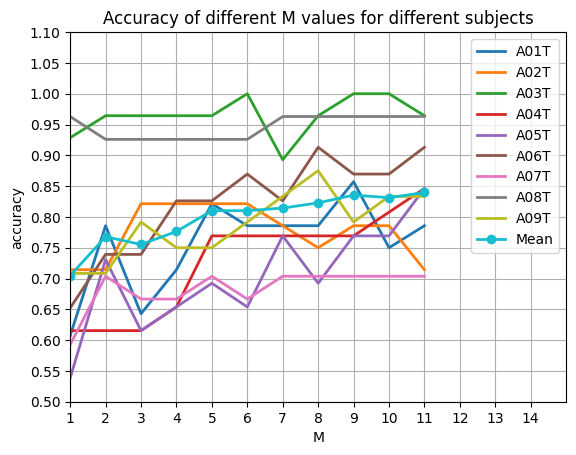

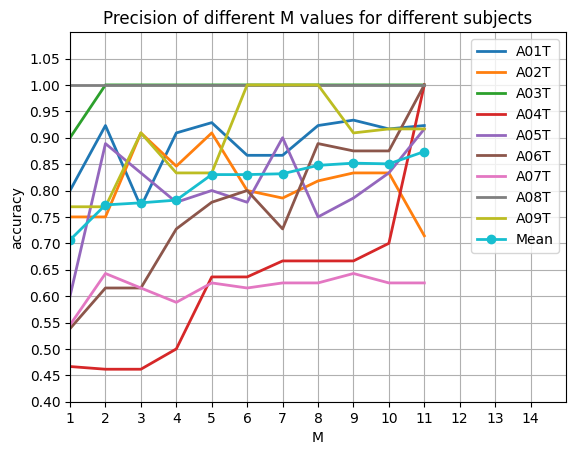

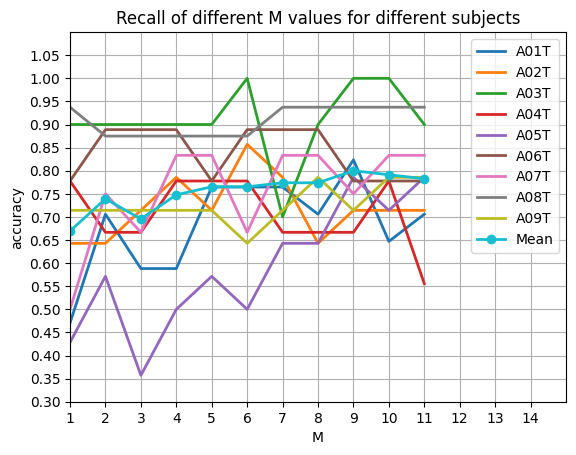

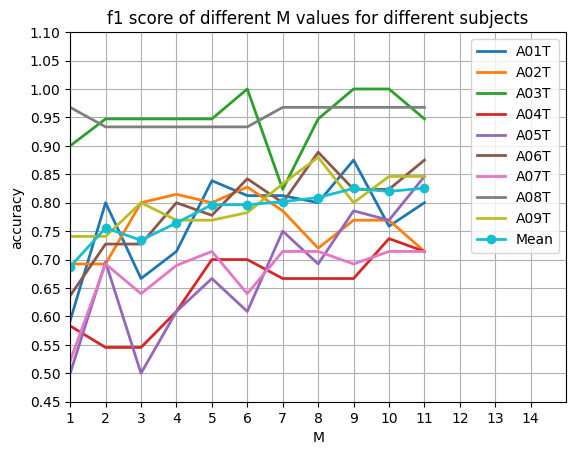

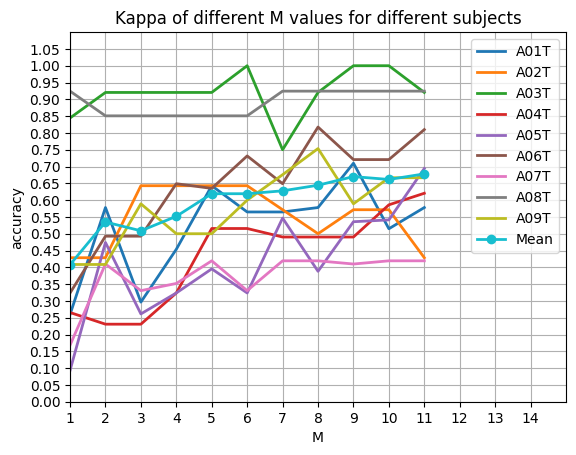

In [ ]:
if doExp1: # 控制要不要做實驗1
    test_acc_all = {}
    test_precision_all = {}
    test_recall_all = {}
    test_f1_all = {}
    test_kappa_all = {}
    for subject in participants:
        test_acc_all[subject] = []
        test_precision_all[subject] = []
        test_recall_all[subject] = []
        test_f1_all[subject] = []
        test_kappa_all[subject] = []

    for subject in participants:
        for M in M_list:
            TP = classification_results[subject][M]['confusion_matrix'][0][0]
            TN = classification_results[subject][M]['confusion_matrix'][0][1]
            FN = classification_results[subject][M]['confusion_matrix'][1][0]
            FP = classification_results[subject][M]['confusion_matrix'][1][1]
            test_trials = classification_results[subject][M]['confusion_matrix'].sum()

            test_acc  = (TP+FP)/test_trials
            test_precision = TP/(TP+FN)
            test_recall = TP/(TP+TN)
            test_f1 = (2*test_precision*test_recall)/(test_precision+test_recall)
            test_pe = ((TP+FN)/test_trials)*((TP+TN)/test_trials)+((TN+FP)/test_trials)*((FN+FP)/test_trials)
            test_kappa = (test_acc-test_pe)/(1-test_pe)

            test_acc_all[subject] = test_acc_all[subject] + [test_acc]
            test_precision_all[subject] = test_precision_all[subject] + [test_precision]
            test_recall_all[subject] = test_recall_all[subject] + [test_recall]
            test_f1_all[subject] = test_f1_all[subject] + [test_f1]
            test_kappa_all[subject] = test_kappa_all[subject] + [test_kappa]

    # all subjects average
    test_acc_avg = np.zeros([11,])
    test_precision_avg = np.zeros([11,])
    test_recall_avg = np.zeros([11,])
    test_f1_avg = np.zeros([11,])
    test_kappa_avg = np.zeros([11,])
    confusion_matrix_allSubjectSum = {}
    for M in M_list:
        confusion_matrix_allSubjectSum[M] = np.zeros([2,2])

    for idx, M in enumerate(M_list):
        test_trials_all = 0
        for subject in participants:
            confusion_matrix_allSubjectSum[M] += classification_results[subject][M]['confusion_matrix']
        TP = confusion_matrix_allSubjectSum[M][0][0]
        TN = confusion_matrix_allSubjectSum[M][0][1]
        FN = confusion_matrix_allSubjectSum[M][1][0]
        FP = confusion_matrix_allSubjectSum[M][1][1]
        test_trials = confusion_matrix_allSubjectSum[M].sum()
        test_acc_avg[idx]  = (TP+FP)/test_trials
        test_precision_avg[idx] = TP/(TP+FN)
        test_recall_avg[idx] = TP/(TP+TN)
        test_f1_avg[idx] = (2*test_precision_avg[idx]*test_recall_avg[idx])/(test_precision_avg[idx]+test_recall_avg[idx])
        test_pe = ((TP+FN)/test_trials)*((TP+TN)/test_trials)+((TN+FP)/test_trials)*((FN+FP)/test_trials)
        test_kappa_avg[idx] = (test_acc_avg[idx]-test_pe)/(1-test_pe)



    # plot
    fig, ax = plt.subplots()
    for idx, subject in enumerate(participants):
        ax.plot(M_list, test_acc_all[subject], linewidth=2.0)
    ax.plot(M_list, test_acc_avg, 'o-', linewidth=2)
    ax.set_title(f"Accuracy of different M values for different subjects")
    ax.set_xlabel("M")
    ax.set_ylabel("accuracy")
    ax.legend(participants+[f"Mean"], loc = 1)
    ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
        ylim=(0.5, 1.1), yticks=np.arange(0.5, 1.1,.05))
    plt.grid()
    fig.savefig("exp1_acc")
    # precision    
    fig, ax = plt.subplots()
    for idx, subject in enumerate(participants):
        ax.plot(M_list, test_precision_all[subject], linewidth=2.0)
    ax.plot(M_list, test_precision_avg, 'o-', linewidth=2)
    ax.set_title(f"Precision of different M values for different subjects")
    ax.set_xlabel("M")
    ax.set_ylabel("accuracy")
    ax.legend(participants+[f"Mean"], loc = 1)
    ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
        ylim=(0.4, 1.1), yticks=np.arange(0.4, 1.1,.05))
    plt.grid()
    fig.savefig("exp1_precision")
    # recall
    fig, ax = plt.subplots()
    for idx, subject in enumerate(participants):
        ax.plot(M_list, test_recall_all[subject], linewidth=2.0)
    ax.plot(M_list, test_recall_avg, 'o-', linewidth=2)
    ax.set_title(f"Recall of different M values for different subjects")
    ax.set_xlabel("M")
    ax.set_ylabel("accuracy")
    ax.legend(participants+[f"Mean"], loc = 1)
    ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
        ylim=(0.3, 1.1), yticks=np.arange(0.3, 1.1,.05))
    plt.grid()
    fig.savefig("exp1_recall")
    # f1 score
    fig, ax = plt.subplots()
    for idx, subject in enumerate(participants):
        ax.plot(M_list, test_f1_all[subject], linewidth=2.0)
    ax.plot(M_list, test_f1_avg, 'o-', linewidth=2)
    ax.set_title(f"f1 score of different M values for different subjects")
    ax.set_xlabel("M")
    ax.set_ylabel("accuracy")
    ax.legend(participants+[f"Mean"], loc = 1)
    ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
        ylim=(0.45, 1.1), yticks=np.arange(0.45, 1.1,.05))
    plt.grid()
    fig.savefig("exp1_f1")
    # kappa
    fig, ax = plt.subplots()
    for idx, subject in enumerate(participants):
        ax.plot(M_list, test_kappa_all[subject], linewidth=2.0)
    ax.plot(M_list, test_kappa_avg, 'o-', linewidth=2)
    ax.set_title(f"Kappa of different M values for different subjects")
    ax.set_xlabel("M")
    ax.set_ylabel("accuracy")
    ax.legend(participants+[f"Mean"], loc = 1)
    ax.set(xlim=(1, 15), xticks=np.arange(1, 15),
        ylim=(0., 1.1), yticks=np.arange(0., 1.1,.05))
    plt.grid()
    fig.savefig("exp1_kappa")
    plt.show()



# 實踐2: FBCSP

In [73]:
subject_data[subject]['all']['trs'].shape
a = np.array(np.zeros([3,10]))
b = np.array(np.ones([3,10]))
c = np.append(a, b, axis=1)
c



array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.]])

In [ ]:
# bands, trials, ch, sample
for subject in participants:

     ch = 9
     timeStart = 3
     timeStop = 6
     # subject_data[subject]['all']['trs']
     # subject_data[subject]['all']['cls']

     bands = []

     fs = 250  # Sampling frequency
     lowcut = 8  # Low cutoff frequency
     highcut = 30  # High cutoff frequency
     order = 8  # Filter order
     subbandwidth = 4
     bandnumber = int((highcut-lowcut)/subbandwidth)

     for i in range(bandnumber):
          bands.append([lowcut+i*subbandwidth, lowcut+(i+1)*subbandwidth])

     subject_data[subject]['bands'] = {}

     for idx, band in enumerate(bands):
          filter = bandpass_filter(band[0], band[1], fs, order)
          trials = subject_data[subject]['all']['trs'].shape[1]
          for  trial in range(trials):
               filtered_data = signal.filtfilt(filter.b, filter.a, subject_data[subject]['all']['trs'][trial, ch, timeStart*fs:timeStop*fs])
               subject_data[subject]['bands'][f'{idx}'] = filtered_data

